# 2-D Transient Heat Conduction: Explicit vs Implicit Finite Volume Method

**Problem:** unit square plate, initially at 0. Left wall held at 100, other three walls at 0.

$$\frac{\partial T}{\partial t} = \alpha\left(\frac{\partial^2 T}{\partial x^2}+\frac{\partial^2 T}{\partial y^2}\right)$$

- `Nx × Ny` cells, temperature at cell centres, walls applied via a half-cell flux (`2·T_wall − T`).
- $r_x = \alpha\Delta t/\Delta x^2$, $r_y = \alpha\Delta t/\Delta y^2$. **Explicit** is stable only if $r_x + r_y \le 0.5$; **implicit** is unconditionally stable.
- The exact series solution is averaged over each cell so it compares fairly with the FVM values.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags, identity, kron
from scipy.sparse.linalg import splu

%matplotlib inline

alpha, T_left, T_right, T_bottom, T_top = 0.01, 100.0, 0.0, 0.0, 0.0
t_end = 20.0                      # unit square, Lx = Ly = 1

# ---- change these for the single run ----
Nx, Ny = 12, 12                   # cells in x and y
s_exp  = 0.3                      # explicit: rx + ry (must be <= 0.5)
dt_imp = 1.0                      # implicit time step

## Solvers

In [2]:
def explicit(Nx, Ny, s, t=t_end):
    """Forward Euler; dt is chosen so that rx + ry = s. Returns (T, rx+ry, steps)."""
    dx, dy = 1.0 / Nx, 1.0 / Ny
    dt = s / (alpha * (1 / dx**2 + 1 / dy**2))
    steps = int(np.ceil(t / dt)); dt = t / steps
    rx, ry = alpha * dt / dx**2, alpha * dt / dy**2
    T  = np.zeros((Ny, Nx))
    Tp = np.zeros((Ny + 2, Nx + 2))                   # padded array holding ghost (wall) values
    with np.errstate(all="ignore"):
        for _ in range(steps):
            Tp[1:-1, 1:-1] = T
            Tp[1:-1, 0]  = 2 * T_left   - T[:, 0]     # ghost value gives half-cell wall flux
            Tp[1:-1, -1] = 2 * T_right  - T[:, -1]
            Tp[0, 1:-1]  = 2 * T_bottom - T[0, :]
            Tp[-1, 1:-1] = 2 * T_top    - T[-1, :]
            T = (T + rx * (Tp[1:-1, 2:] - 2 * T + Tp[1:-1, :-2])
                   + ry * (Tp[2:, 1:-1] - 2 * T + Tp[:-2, 1:-1]))
    return T, rx + ry, steps

def implicit(Nx, Ny, dt, t=t_end):
    """Backward Euler with a sparse matrix, factorised once. Returns (T, rx+ry, steps)."""
    dx, dy = 1.0 / Nx, 1.0 / Ny
    steps = int(np.ceil(t / dt)); dt = t / steps
    rx, ry = alpha * dt / dx**2, alpha * dt / dy**2

    def lap1d(n):                                     # 1-D second difference, wall cells = -3
        d = diags([np.ones(n - 1), -2 * np.ones(n), np.ones(n - 1)], [-1, 0, 1]).tolil()
        d[0, 0] = -3; d[-1, -1] = -3
        return d.tocsc()

    K  = rx * kron(identity(Ny), lap1d(Nx)) + ry * kron(lap1d(Ny), identity(Nx))
    lu = splu((identity(Nx * Ny) - K).tocsc())        # matrix is constant -> factorise once

    src = np.zeros((Ny, Nx))                          # wall temperature source terms
    src[:, 0]  += 2 * rx * T_left;   src[:, -1] += 2 * rx * T_right
    src[0, :]  += 2 * ry * T_bottom; src[-1, :] += 2 * ry * T_top

    T = np.zeros(Nx * Ny)
    for _ in range(steps): T = lu.solve(T + src.ravel())
    return T.reshape(Ny, Nx), rx + ry, steps

## Exact solution and error measures

In [3]:
def exact(Nx, Ny, t=t_end, nmax=401, mmax=400):
    """Series solution (left wall 100, others 0, initial 0), averaged over each cell."""
    x0 = np.arange(Nx) / Nx; y0 = np.arange(Ny) / Ny
    X0, Y0 = np.meshgrid(x0, y0); X1, Y1 = X0 + 1 / Nx, Y0 + 1 / Ny
    T = np.zeros((Ny, Nx))
    for n in range(1, nmax + 1, 2):
        a = n * np.pi
        # steady part (decays away from the hot wall)
        fx = ((np.exp(-a * X0) - np.exp(-a * X1)) - (np.exp(-a * (2 - X1)) - np.exp(-a * (2 - X0)))) * Nx / a / (1 - np.exp(-2 * a))
        sy = (np.cos(a * Y0) - np.cos(a * Y1)) * Ny / a
        T += 400 / a * sy * fx
        # transient part
        for m in range(1, mmax + 1):
            b = m * np.pi
            sx = (np.cos(b * X0) - np.cos(b * X1)) * Nx / b
            T -= 800 * m / (n * np.pi**2 * (m * m + n * n)) * sx * sy * np.exp(-alpha * np.pi**2 * (m * m + n * n) * t)
    return T

def errors(T, ref):
    """(RMS, max, max in core 0.25<=y<=0.75); nan if the run blew up.
    The corners near the hot wall have a singularity, so the core error is also reported."""
    d = np.abs(T - ref)
    if not np.all(np.isfinite(d)) or d.max() > 1e3: return np.nan, np.nan, np.nan
    yc = (np.arange(T.shape[0]) + 0.5) / T.shape[0]
    core = (yc >= 0.25) & (yc <= 0.75)
    return np.sqrt(np.mean(d**2)), d.max(), d[core].max()

## Single run

explicit: rx+ry = 0.300, steps = 192, errors (RMS, max, core) = 0.424, 2.238, 0.415
implicit: rx+ry = 2.880, steps = 20, errors (RMS, max, core) = 0.460, 2.257, 0.530
explicit vs implicit: max diff = 0.3558, RMS diff = 0.1797


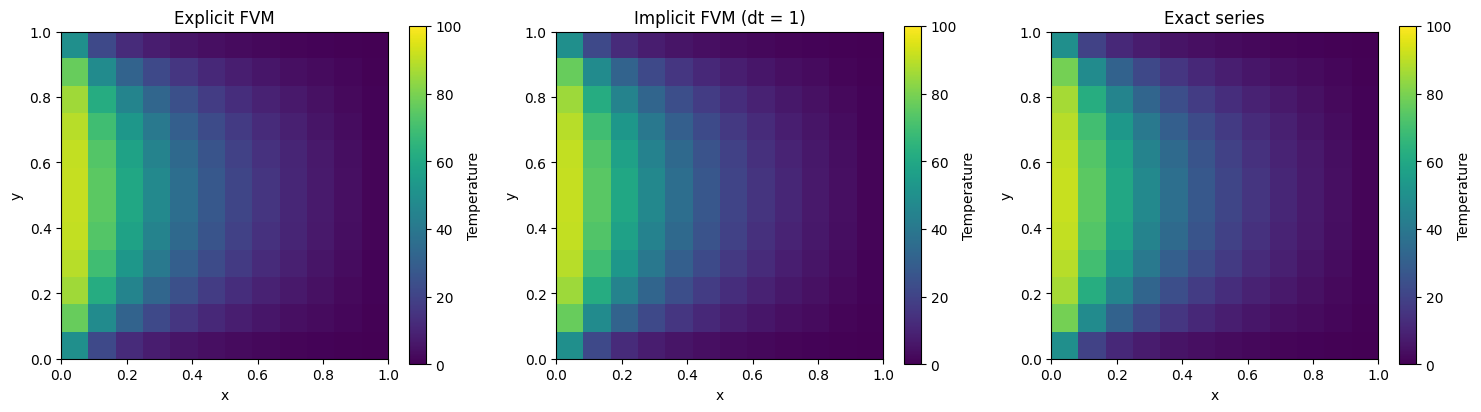

In [4]:
Te, se_, ne = explicit(Nx, Ny, s_exp)
Ti, si_, ni = implicit(Nx, Ny, dt_imp)
ref = exact(Nx, Ny)

print(f"explicit: rx+ry = {se_:.3f}, steps = {ne}, errors (RMS, max, core) = " + ", ".join(f"{v:.3f}" for v in errors(Te, ref)))
print(f"implicit: rx+ry = {si_:.3f}, steps = {ni}, errors (RMS, max, core) = " + ", ".join(f"{v:.3f}" for v in errors(Ti, ref)))
print(f"explicit vs implicit: max diff = {np.max(np.abs(Te - Ti)):.4f}, RMS diff = {np.sqrt(np.mean((Te - Ti)**2)):.4f}")

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, F, title in zip(ax, (Te, Ti, ref), ("Explicit FVM", f"Implicit FVM (dt = {dt_imp:g})", "Exact series")):
    im = a.imshow(F, origin="lower", extent=[0, 1, 0, 1], vmin=0, vmax=100)
    a.set(title=title, xlabel="x", ylabel="y"); plt.colorbar(im, ax=a, label="Temperature")
plt.tight_layout(); plt.show()

## Study 1: number of cells N (Nx = Ny = N)
Explicit uses rx + ry = 0.3, implicit uses dt = 0.1.

In [5]:
Ns = [6, 12, 24, 48]
rows = []
for n in Ns:
    r_ = exact(n, n)
    te, _, se = explicit(n, n, 0.3)
    ti, _, si = implicit(n, n, 0.1)
    rows.append((n, errors(te, r_), errors(ti, r_), se, si))

print(f"{'N':>4} | {'RMS exp':>8} {'max exp':>8} {'core exp':>9} | {'RMS imp':>8} {'max imp':>8} {'core imp':>9} | {'steps exp':>9} {'steps imp':>9}")
for n, e, i, se, si in rows:
    print(f"{n:>4} | {e[0]:>8.3f} {e[1]:>8.3f} {e[2]:>9.4f} | {i[0]:>8.3f} {i[1]:>8.3f} {i[2]:>9.4f} | {se:>9} {si:>9}")

   N |  RMS exp  max exp  core exp |  RMS imp  max imp  core imp | steps exp steps imp
   6 |    0.857    2.345    2.3448 |    0.860    2.376    2.3761 |        48       200
  12 |    0.424    2.238    0.4150 |    0.425    2.242    0.4348 |       192       200
  24 |    0.212    2.234    0.1187 |    0.213    2.235    0.1283 |       768       200
  48 |    0.106    2.235    0.0314 |    0.107    2.235    0.0390 |      3072       200


## Study 2: explicit time step (N = 12)
Sweep rx + ry across the stability limit of 0.5 (`nan` = unstable).

In [6]:
ref12 = exact(12, 12)
s_list = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.52, 0.6]
exp_rows = []
for s in s_list:
    T_, _, st = explicit(12, 12, s)
    exp_rows.append((s, t_end / st, st, errors(T_, ref12)))

print(f"{'rx+ry':>6} {'dt':>8} {'steps':>6} {'RMS':>8} {'max':>8} {'core':>8}")
for s, d, st, e in exp_rows: print(f"{s:>6.2f} {d:>8.4f} {st:>6} {e[0]:>8.4f} {e[1]:>8.3f} {e[2]:>8.4f}")

 rx+ry       dt  steps      RMS      max     core
  0.05   0.0174   1152   0.4240    2.240   0.4233
  0.10   0.0347    576   0.4239    2.239   0.4217
  0.20   0.0694    288   0.4238    2.239   0.4183
  0.30   0.1042    192   0.4238    2.238   0.4150
  0.40   0.1389    144   0.4239    2.238   0.4117
  0.50   0.1724    116   0.4241    2.242   0.4157
  0.52   0.1802    111 133.4242  238.802 146.9495
  0.60   0.2083     96      nan      nan      nan


## Study 3: implicit time step (N = 12)

In [7]:
dts = [0.1, 0.25, 0.5, 1, 2, 5, 10, 20]
imp_rows = []
for d in dts:
    T_, s_a, st = implicit(12, 12, d)
    imp_rows.append((d, s_a, st, errors(T_, ref12)))

print(f"{'dt':>6} {'rx+ry':>7} {'steps':>6} {'RMS':>8} {'max':>8} {'core':>8}")
for d, s_a, st, e in imp_rows: print(f"{d:>6g} {s_a:>7.2f} {st:>6} {e[0]:>8.4f} {e[1]:>8.3f} {e[2]:>8.4f}")

    dt   rx+ry  steps      RMS      max     core
   0.1    0.29    200   0.4249    2.242   0.4348
  0.25    0.72     80   0.4272    2.244   0.4497
   0.5    1.44     40   0.4342    2.248   0.4754
     1    2.88     20   0.4600    2.257   0.5301
     2    5.76     10   0.5547    2.278   0.7689
     5   14.40      4   1.0395    2.361   1.9510
    10   28.80      2   2.0580    4.119   4.1195
    20   57.60      1   4.1844    8.626   8.6260


## Plots

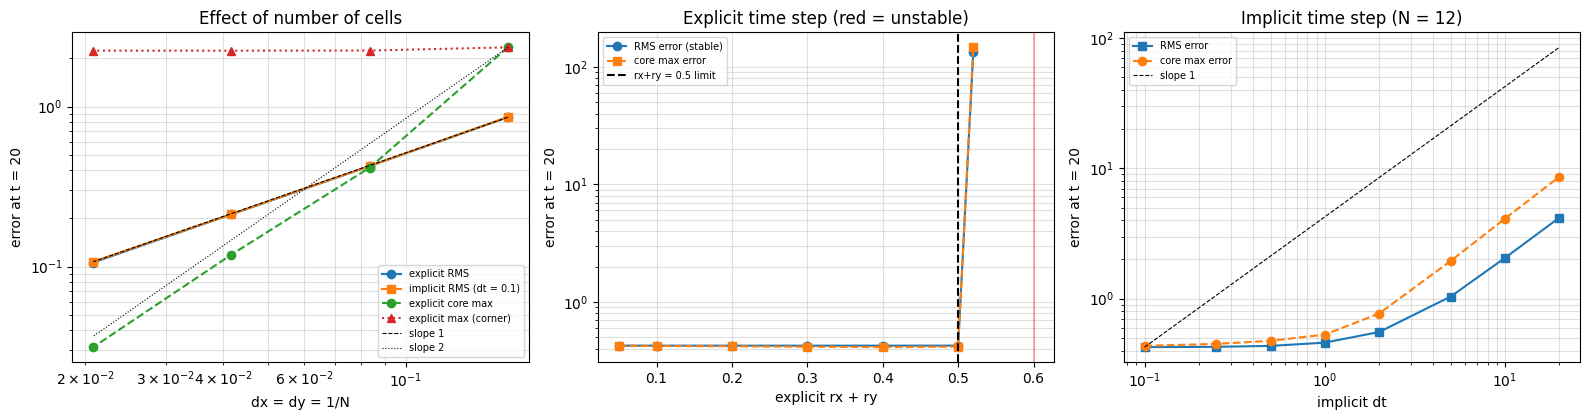

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.3))

# (1) error vs dx: RMS/max ~ first order (corner singularity), core ~ second order
dxs = [1 / r[0] for r in rows]
ax[0].loglog(dxs, [r[1][0] for r in rows], "o-",  label="explicit RMS")
ax[0].loglog(dxs, [r[2][0] for r in rows], "s-",  label="implicit RMS (dt = 0.1)")
ax[0].loglog(dxs, [r[1][2] for r in rows], "o--", label="explicit core max")
ax[0].loglog(dxs, [r[1][1] for r in rows], "^:",  label="explicit max (corner)")
ax[0].loglog(dxs, [rows[0][1][0] * d / dxs[0] for d in dxs], "k--", lw=0.8, label="slope 1")
ax[0].loglog(dxs, [rows[0][1][2] * (d / dxs[0])**2 for d in dxs], "k:", lw=0.8, label="slope 2")
ax[0].set(xlabel="dx = dy = 1/N", ylabel=f"error at t = {t_end:g}", title="Effect of number of cells")

# (2) explicit: error vs rx+ry, unstable runs marked red
ok = [r for r in exp_rows if np.isfinite(r[3][0])]
ax[1].semilogy([r[0] for r in ok], [r[3][0] for r in ok], "o-",  label="RMS error (stable)")
ax[1].semilogy([r[0] for r in ok], [r[3][2] for r in ok], "s--", label="core max error")
for r in exp_rows:
    if not np.isfinite(r[3][0]): ax[1].axvline(r[0], color="r", alpha=0.3)
ax[1].axvline(0.5, color="k", ls="--", label="rx+ry = 0.5 limit")
ax[1].set(xlabel="explicit rx + ry", ylabel=f"error at t = {t_end:g}", title="Explicit time step (red = unstable)")

# (3) implicit: error vs dt
ax[2].loglog(dts, [r[3][0] for r in imp_rows], "s-",  label="RMS error")
ax[2].loglog(dts, [r[3][2] for r in imp_rows], "o--", label="core max error")
ax[2].loglog(dts, [imp_rows[0][3][0] * d / dts[0] for d in dts], "k--", lw=0.8, label="slope 1")
ax[2].set(xlabel="implicit dt", ylabel=f"error at t = {t_end:g}", title="Implicit time step (N = 12)")

for a in ax: a.grid(alpha=0.4, which="both"); a.legend(fontsize=7)
plt.tight_layout(); plt.show()